In [1]:
!python -m pip install pyyaml==6.0.2
import sys,os,distutils.core
!git clone 'https://github.com/facebookresearch/detectron2'
dist=distutils.core.run_setup('detectron2/setup.py')
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0,os.path.abspath('detectron2'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3
Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 15943 (delta 4), reused 2 (delta 2), pack-reused 15930 (from 2)
Receiving objects: 100% (15943/15943), 6.71 MiB | 8.36 MiB/s, done.
Resolving deltas: 100% (11333/11333), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
import torch,detectron2
!nvcc --version
TORCH_VERSION=".".join(torch.__version__.split(".")[:2])
CUDA_VERSION=torch.__version__.split("+")[-1]
print("torch: ",TORCH_VERSION,"cuda: ",CUDA_VERSION)
print("detectron2:",detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
torch:  2.10 cuda:  cu128
detectron2: 0.6


In [3]:
import detectron2
import numpy as np
import os,json,cv2,random
from google.colab.patches import cv2_imshow
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog

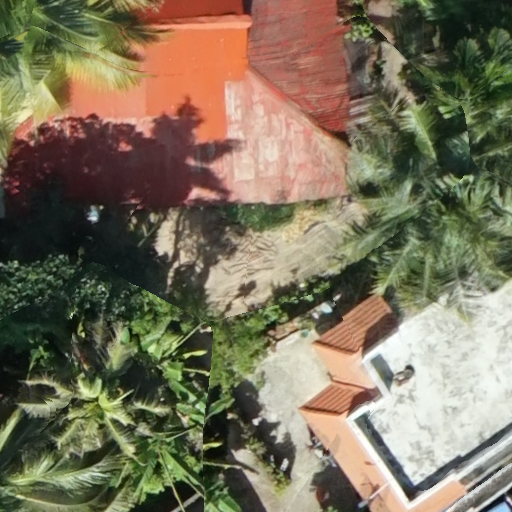

In [ ]:
my_new_image = cv2.imread("/content/drive/MyDrive/My_dataset/train/03afaa9b-image_0422.png")
cv2_imshow(my_new_image)

model_final_a6e10b.pkl: 237MB [00:01, 141MB/s]                           
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0223 05:27:01.665000 402 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


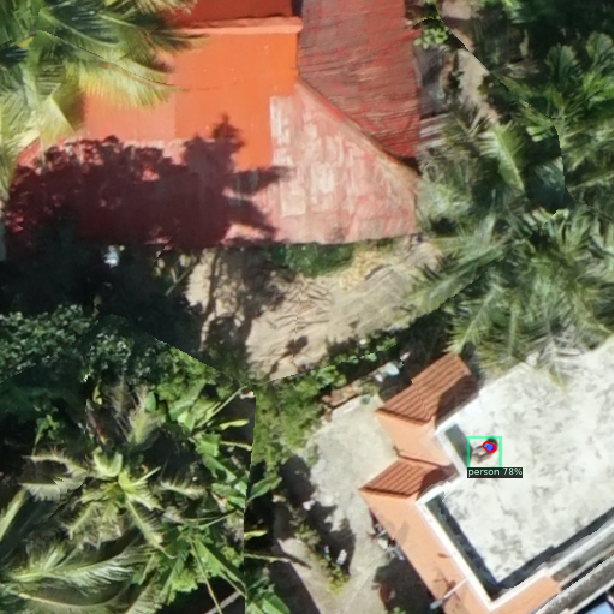

In [ ]:
cfg_keypoint = get_cfg()   # get a fresh new config
cfg_keypoint.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg_keypoint.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
cfg_keypoint.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg_keypoint)
outputs = predictor(my_new_image)
v = Visualizer(my_new_image[:,:,::-1], MetadataCatalog.get(cfg_keypoint.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])

In [4]:
cfg_inst = get_cfg()
cfg_inst.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg_inst.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo.  https://github.com/facebookresearch/detectron2/blob/main/MODEL_ZOO.md
cfg_inst.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg_inst)
outputs = predictor(my_new_image)

v = Visualizer(my_new_image[:, :, ::-1], MetadataCatalog.get(cfg_inst.DATASETS.TRAIN[0]), scale=1.0)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])

model_final_f10217.pkl: 178MB [00:00, 211MB/s]                           


NameError: name 'my_new_image' is not defined

In [5]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("my_dataset_train", {}, "/content/drive/MyDrive/My_dataset/annotations_train.json", "/content/drive/MyDrive/My_dataset/train")
register_coco_instances("my_dataset_val", {}, "/content/drive/MyDrive/My_dataset/annotations_val.json", "/content/drive/MyDrive/My_dataset/val")



In [6]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



In [7]:
val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")


Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



In [8]:
from matplotlib import pyplot as plt

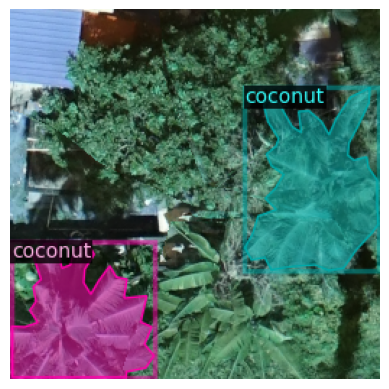

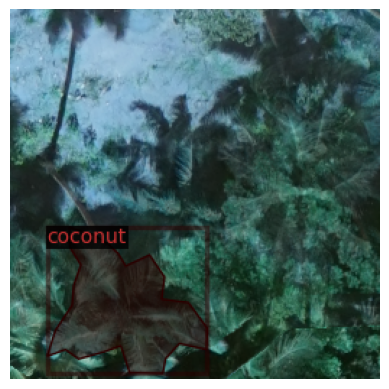

In [9]:
for d in random.sample(train_dataset_dicts, 2):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=train_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.axis("off")
    plt.show()

In [10]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.OUTPUT_DIR = "/content/drive/MyDrive/ColabNotebooks/models/Detectron2_Models"
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 10000    # 1000 iterations seems good enough for this dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256   # Default is 512, using 256 for this dataset.
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # We have 2 classes.
# NOTE: this config means the number of classes, without the background. Do not use num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) #Create an instance of of DefaultTrainer with the given congiguration
trainer.resume_or_load(resume=False) #Load a pretrained model if available (resume training) or start training from scratch if no pretrained model is available


[02/24 04:47:12 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


In [ ]:
trainer.train() #Start the training process

[02/23 05:28:49 d2.engine.train_loop]: Starting training from iteration 0
[02/23 05:29:03 d2.utils.events]:  eta: 1:27:17  iter: 19  total_loss: 1.697  loss_cls: 0.5809  loss_box_reg: 0.2945  loss_mask: 0.693  loss_rpn_cls: 0.1177  loss_rpn_loc: 0.01585    time: 0.5456  last_time: 0.4448  data_time: 0.2359  last_data_time: 0.1721   lr: 4.9953e-06  max_mem: 2074M
[02/23 05:29:23 d2.utils.events]:  eta: 1:30:48  iter: 39  total_loss: 1.525  loss_cls: 0.5284  loss_box_reg: 0.2572  loss_mask: 0.6922  loss_rpn_cls: 0.05687  loss_rpn_loc: 0.009164    time: 0.5535  last_time: 0.7971  data_time: 0.2111  last_data_time: 0.4242   lr: 9.9902e-06  max_mem: 2074M
[02/23 05:29:34 d2.utils.events]:  eta: 1:30:10  iter: 59  total_loss: 1.516  loss_cls: 0.4276  loss_box_reg: 0.3048  loss_mask: 0.691  loss_rpn_cls: 0.071  loss_rpn_loc: 0.01425    time: 0.5592  last_time: 0.4541  data_time: 0.2172  last_data_time: 0.1410   lr: 1.4985e-05  max_mem: 2140M
[02/23 05:29:46 d2.utils.events]:  eta: 1:30:26  it

In [ ]:
%load_ext tensorboard
%tensorboard --logdir output


In [11]:
import json
import pandas as pd

metrics_file = "/content/drive/MyDrive/ColabNotebooks/models/Detectron2_Models/metrics.json"

data = []
with open(metrics_file, "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)


In [12]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[02/24 04:47:35 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/ColabNotebooks/models/Detectron2_Models/model_final.pth ...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0224 04:47:48.590000 1522 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


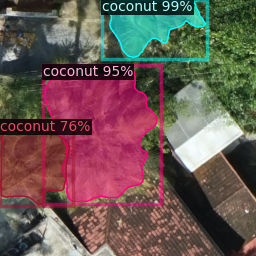

In [13]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(val_dataset_dicts, 1):    #select number of images for display
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                   metadata=val_metadata,
                   scale=0.5,
                   instance_mode=ColorMode.IMAGE  # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    cv2_imshow(out.get_image()[:, :, ::-1])

In [14]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator = COCOEvaluator("my_dataset_val", output_dir="./output")
val_loader = build_detection_test_loader(cfg, "my_dataset_val")
results = inference_on_dataset(predictor.model, val_loader, evaluator)
print(inference_on_dataset(predictor.model, val_loader, evaluator))

[02/24 04:48:02 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [02/24 04:48:02 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[02/24 04:48:02 d2.data.datasets.coco]: Loaded 374 images in COCO format from /content/drive/MyDrive/My_dataset/annotations_val.json
[02/24 04:48:02 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
|  coconut   | 755          |
|            |              |
[02/24 04:48:02 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[02/24 04:48:02 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[02/24 04:48:02 d2.data.common]: Serializing 374 elements to byte tensors and concatenating them all ...
[02/24 04:48

In [15]:
import pandas as pd

df_1 = pd.DataFrame(results).T
df_1


,AP,AP50,AP75,APs,APm,APl
bbox,72.643532,94.377947,84.989280,NaN,64.847495,73.294825
segm,63.425104,94.490901,79.284233,NaN,44.148269,64.162463


In [16]:
df_2=df

In [17]:
df_2

,data_time,eta_seconds,fast_rcnn/cls_accuracy,fast_rcnn/false_negative,fast_rcnn/fg_cls_accuracy,iteration,loss_box_reg,loss_cls,loss_mask,loss_rpn_cls,...,mask_rcnn/accuracy,mask_rcnn/false_negative,mask_rcnn/false_positive,rank_data_time,roi_head/num_bg_samples,roi_head/num_fg_samples,rpn/num_neg_anchors,rpn/num_pos_anchors,time,total_loss
0,0.005475,115.421047,0.115234,0.068182,0.615642,19,0.207406,1.201970,0.692663,0.373994,...,0.543213,0.696608,0.242883,0.005475,235.25,20.75,232.00,24.00,0.412218,2.525662
1,0.005454,104.548789,0.835938,0.970513,0.012195,39,0.331849,0.903024,0.691395,0.262430,...,0.605418,0.337250,0.337102,0.005454,228.00,28.00,229.00,27.00,0.370861,2.257015
2,0.006459,97.914300,0.837891,1.000000,0.000000,59,0.538491,0.644256,0.688454,0.142687,...,0.672266,0.157713,0.485318,0.006459,214.50,41.50,229.75,26.25,0.419072,2.056833
3,0.005400,90.214060,0.837891,1.000000,0.000000,79,0.556100,0.546956,0.684241,0.093759,...,0.671409,0.092014,0.619828,0.005400,214.50,41.50,232.25,23.75,0.416909,1.945591
4,0.005681,82.587811,0.800781,1.000000,0.000000,99,0.678018,0.582825,0.679904,0.077341,...,0.656278,0.067119,0.641446,0.005681,205.00,51.00,232.50,23.50,0.430167,2.114596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,0.006516,32.194918,0.976562,0.045549,0.954451,9919,0.118625,0.054982,0.156649,0.000148,...,0.932365,0.048873,0.091571,0.006516,220.25,35.75,250.25,5.75,0.411582,0.320939
642,0.006318,24.152879,0.969727,0.076082,0.923918,9939,0.135757,0.066266,0.165681,0.000217,...,0.925676,0.057766,0.077503,0.006318,213.25,42.75,248.00,8.00,0.385486,0.385763
643,0.006860,16.101920,0.981445,0.048680,0.951320,9959,0.103242,0.047214,0.161357,0.000113,...,0.931219,0.054884,0.075874,0.006860,214.25,41.75,249.25,6.75,0.398446,0.324616
644,0.005685,8.049452,0.973633,0.074656,0.925344,9979,0.137670,0.064525,0.173151,0.000255,...,0.927922,0.053727,0.099262,0.005685,213.75,42.25,249.25,6.75,0.381771,0.379340


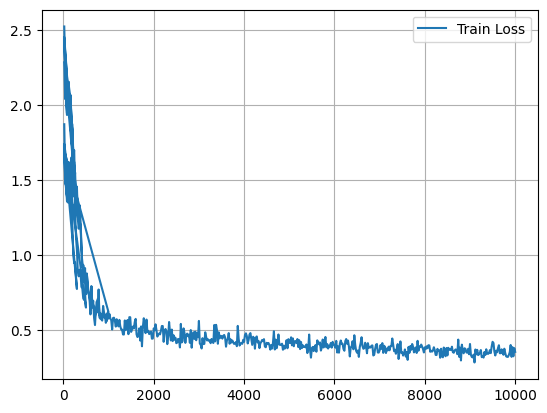

In [18]:
import matplotlib.pyplot as plt

plt.plot(df_2["iteration"], df_2["total_loss"], label="Train Loss")
#plt.plot(df["iteration"], df_1["AP"], label="Val AP")

plt.legend()
plt.grid(True)
plt.show()


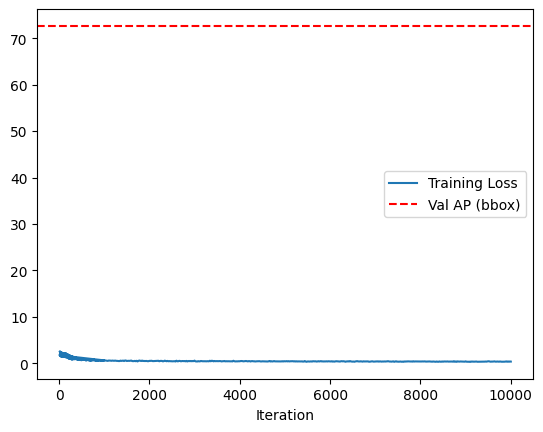

In [ ]:
import matplotlib.pyplot as plt

final_ap = df_1.loc["bbox", "AP"]

plt.plot(df_2["iteration"], df_2["total_loss"], label="Training Loss")
plt.axhline(final_ap, color="red", linestyle="--", label="Val AP (bbox)")

plt.xlabel("Iteration")
plt.legend()
plt.show()


In [19]:
new_im = cv2.imread("/content/drive/MyDrive/My_dataset/test_1/tile_14336_4096.png")
outputs  = predictor(new_im)

# We can use `Visualizer` to draw the predictions on the image.
v = Visualizer(new_im[:, :, ::-1], metadata=train_metadata)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

cv2_imshow(out.get_image()[:, :, ::-1])


Output hidden; open in https://colab.research.google.com to view.

In [20]:
# Directory path to the input images folder
input_images_directory = "/content/drive/MyDrive/My_dataset/train"

# Output directory where the segmented images will be saved
output_directory = "/content/drive/MyDrive/My_dataset/train_mask"  # Replace this with the path to your desired output directory

# Loop over the images in the input folder
for image_filename in os.listdir(input_images_directory):
    image_path = os.path.join(input_images_directory, image_filename)
    new_im = cv2.imread(image_path)

    # Perform prediction on the new image
    outputs = predictor(new_im)  # Format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format

    # We can use `Visualizer` to draw the predictions on the image.
    v = Visualizer(new_im[:, :, ::-1], metadata=train_metadata)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    # Create the output filename with _result extension
    result_filename = os.path.splitext(image_filename)[0] + "_result.png"
    output_path = os.path.join(output_directory, result_filename)

    # Save the segmented image
    cv2.imwrite(output_path, out.get_image()[:, :, ::-1])

print("Segmentation of all images completed.")

KeyboardInterrupt: 

In [ ]:
import csv
from skimage.measure import regionprops, label


# Assuming you have already defined the 'predictor' object and loaded the model.
# Also, make sure 'metadata' is defined appropriately.

# Directory path to the input images folder
input_images_directory = "/content/drive/MyDrive/My_dataset/test_1"

# Output directory where the CSV file will be saved
output_csv_path = "/content/drive/MyDrive/My_dataset/test_results/output_objects.csv"  # Replace this with the path to your desired output CSV file

# Open the CSV file for writing
with open(output_csv_path, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)

    # Write the header row in the CSV file
    csvwriter.writerow(["File Name", "Class Name", "Object Number", "Area", "Centroid", "BoundingBox"])  # Add more columns as needed for other properties

    # Loop over the images in the input folder
    for image_filename in os.listdir(input_images_directory):
        image_path = os.path.join(input_images_directory, image_filename)
        new_im = cv2.imread(image_path)

        # Perform prediction on the new image
        outputs = predictor(new_im)  # Format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format

        # Convert the predicted mask to a binary mask
        mask = outputs["instances"].pred_masks.to("cpu").numpy().astype(bool)

        # Get the predicted class labels
        class_labels = outputs["instances"].pred_classes.to("cpu").numpy()

        # Debugging: print class_labels and metadata.thing_classes
        #print("Class Labels:", class_labels)
        #print("Thing Classes:", train_metadata.thing_classes)

        # Use skimage.measure.regionprops to calculate object parameters
        if mask.size == 0:
           continue

        labeled_mask = label(mask)
        if labeled_mask.max() == 0:
          continue
        props = regionprops(labeled_mask)

        # Write the object-level information to the CSV file
        for i, prop in enumerate(props):
            object_number = i + 1  # Object number starts from 1
            area = prop.area
            centroid = prop.centroid
            bounding_box = prop.bbox

            # Check if the corresponding class label exists
            if i < len(class_labels):
                class_label = class_labels[i]
                class_name = train_metadata.thing_classes[class_label]
            else:
                # If class label is not available (should not happen), use 'Unknown' as class name
                class_name = 'Unknown'

            # Write the object-level information to the CSV file
            csvwriter.writerow([image_filename, class_name, object_number, area, centroid, bounding_box])  # Add more columns as needed for other properties

print("Object-level information saved to CSV file.")


Object-level information saved to CSV file.


In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/My_dataset/test_results/output_objects.csv")

In [ ]:
data.head(20)

,File Name,Class Name,Object Number,Area,BoundingBox,polygon_vertices,centroid
0,tile_14336_2048.png,coconut,1,13586.0,"(0, 8, 19, 1, 118, 179)","(64.0, 0.0, 64.0, 58.89371411747387, 64.0, 97....","(64.0, 52.29375828058295)"
1,tile_14336_7168.png,coconut,1,12984.0,"(0, 892, 61, 1, 1012, 210)","(64.0, 0.0, 64.0, 952.998998767714, 64.0, 136....","(64.0, 363.2669182583693)"
2,tile_14336_7168.png,coconut,2,33051.0,"(1, 710, 609, 2, 984, 795)","(64.0, 1.0, 64.0, 850.0289249947051, 64.0, 702...","(64.0, 517.700886508729)"
3,tile_14336_7168.png,coconut,3,22913.0,"(2, 83, 1, 3, 251, 198)","(64.0, 2.0, 64.0, 160.31117706105704, 64.0, 84...","(64.0, 82.24168230553252)"
4,tile_14336_7168.png,coconut,4,20302.0,"(3, 421, 110, 4, 594, 274)","(64.0, 3.0, 64.0, 500.2833710964437, 64.0, 192...","(64.0, 231.94998850687944)"
5,tile_14336_7168.png,coconut,5,13101.0,"(4, 398, 287, 5, 535, 425)","(64.0, 4.0, 64.0, 461.2349438974124, 64.0, 353...","(64.0, 272.7836297483653)"
6,tile_14336_7168.png,coconut,6,13609.0,"(5, 6, 679, 6, 136, 815)","(64.0, 5.0, 64.0, 71.13006098905136, 64.0, 744...","(64.0, 273.4694197467362)"
7,tile_14336_7168.png,coconut,7,11937.0,"(6, 4, 832, 7, 112, 977)","(64.0, 6.0, 64.0, 55.08955348915138, 64.0, 899...","(64.0, 320.1511825975259)"
8,tile_14336_7168.png,coconut,8,21433.0,"(7, 617, 377, 8, 807, 552)","(64.0, 7.0, 64.0, 725.7040078383801, 64.0, 468...","(64.0, 400.45812532076707)"
9,tile_14336_7168.png,coconut,9,16040.0,"(8, 800, 447, 9, 960, 597)","(64.0, 8.0, 64.0, 880.3559850374065, 64.0, 530...","(64.0, 472.92647547797174)"


In [ ]:
data = data.rename(columns={ "Polygon":"polygon_vertices"})

In [ ]:
import numpy as np

def compute_centroid(vertices):
    x_coords = vertices[::2]  # every even index → x
    y_coords = vertices[1::2] # every odd index → y
    centroid_x = np.mean(x_coords)
    centroid_y = np.mean(y_coords)
    return (centroid_x, centroid_y)

# Apply to your DataFrame
data["centroid"] = data["polygon_vertices"].apply(compute_centroid)


In [ ]:
data=data.drop("Centroid",axis=1)

In [ ]:
type(data.loc[0, "Centroid"])


str

In [ ]:
import re

# Function to convert the string into a tuple of floats
def parse_np_string(s):
    # Find all numbers in the string
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", s)
    # Convert to float and return as tuple
    return tuple(map(float, nums))

# Apply to the column
data["Centroid"] = data["Centroid"].apply(parse_np_string)


In [ ]:
data["Centroid"][0]

(64.0, 0.0, 64.0, 58.89371411747387, 64.0, 97.98756072427499)

In [ ]:
data.dtypes

,0
File Name,object
Class Name,object
Object Number,int64
Area,float64
Centroid,object
BoundingBox,object


/tmp/ipython-input-4204423758.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class Name", y="Object Number", data=avg_objects_per_class, palette=["orange", "blue"], order=class_names)


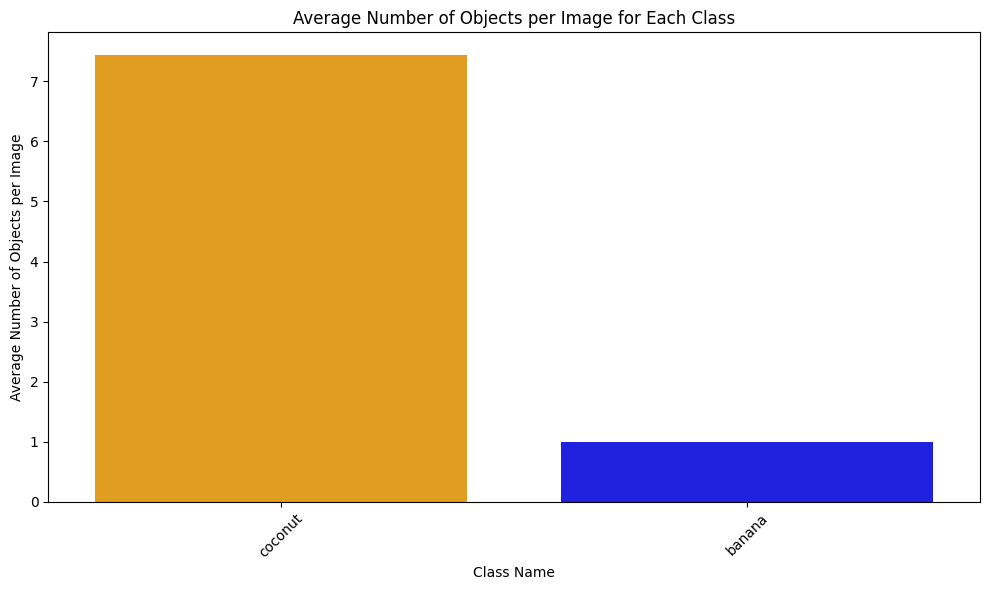

/tmp/ipython-input-4204423758.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class Name", y="Area", data=avg_area_per_class, palette=["orange", "blue"], order=class_names)


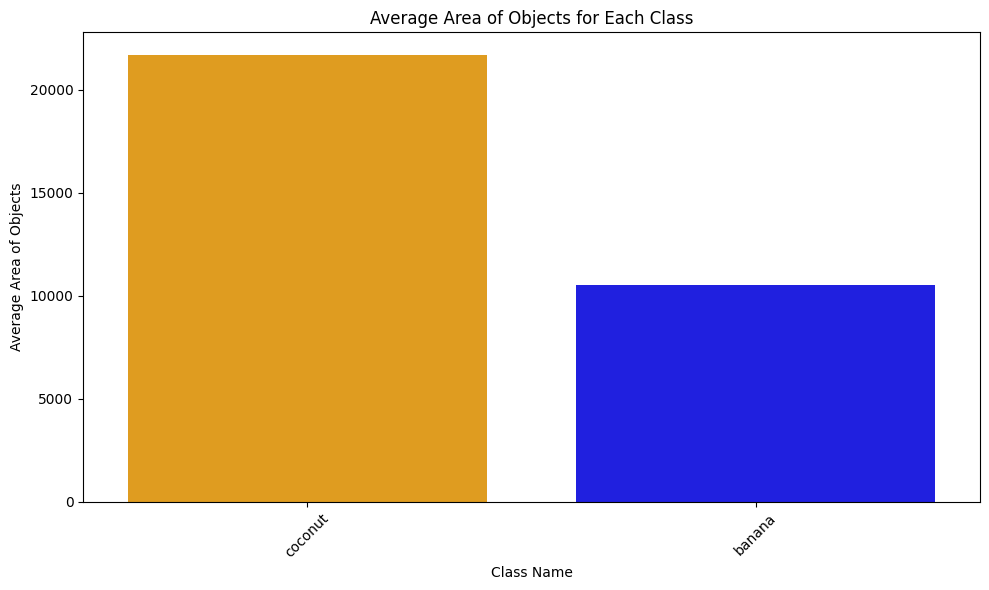

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to the CSV file containing the object-level information
csv_file_path = "/content/drive/MyDrive/My_dataset/test_results/output_objects.csv"  # Update with your CSV file path

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Get class names from train_metadata.thing_classes
class_names = train_metadata.thing_classes

# Group the data by both "File Name" and "Class Name" and calculate the average number of objects per image for each class
# first group the data by both "File Name" and "Class Name" and count the number of objects within each group.
#Then, group the data by "Class Name" only and calculate the mean of the counts, which gives us the average number of objects per image for each class.
avg_objects_per_class = df.groupby(["File Name", "Class Name"])["Object Number"].count().reset_index()
avg_objects_per_class = avg_objects_per_class.groupby("Class Name")["Object Number"].mean().reset_index()

# Plot: Average number of objects per image for each class
plt.figure(figsize=(10, 6))
sns.barplot(x="Class Name", y="Object Number", data=avg_objects_per_class, palette=["orange", "blue"], order=class_names)
plt.xticks(rotation=45)
plt.xlabel("Class Name")
plt.ylabel("Average Number of Objects per Image")
plt.title("Average Number of Objects per Image for Each Class")
plt.tight_layout()
plt.show()


# Group the data by class and calculate the average area of objects for each class
avg_area_per_class = df.groupby("Class Name")["Area"].mean().reset_index()

# Plot: Average area of objects for each class
plt.figure(figsize=(10, 6))
sns.barplot(x="Class Name", y="Area", data=avg_area_per_class, palette=["orange", "blue"], order=class_names)
plt.xticks(rotation=45)
plt.xlabel("Class Name")
plt.ylabel("Average Area of Objects")
plt.title("Average Area of Objects for Each Class")
plt.tight_layout()
plt.show()

In [21]:
import os
import cv2
import numpy as np
import torch

# Directory path to the input images folder
input_images_directory = "/content/drive/MyDrive/My_dataset/train"

# Output directory
output_directory = "/content/drive/MyDrive/My_dataset/train_mask"
os.makedirs(output_directory, exist_ok=True)

for image_filename in os.listdir(input_images_directory):
    image_path = os.path.join(input_images_directory, image_filename)
    new_im = cv2.imread(image_path)

    outputs = predictor(new_im)
    instances = outputs["instances"]

    # 🔴 SKIP images with no detections
    if len(instances) == 0:
        continue

    H, W = instances.image_size

    # Create empty mask per class
    class_masks = {
        class_name: torch.zeros((H, W), dtype=torch.uint8, device=instances.pred_masks.device)
        for class_name in train_metadata.thing_classes
    }

    # Fill masks
    for i, pred_class in enumerate(instances.pred_classes):
        class_name = train_metadata.thing_classes[pred_class]
        class_masks[class_name] = torch.where(
            instances.pred_masks[i],
            i + 1,
            class_masks[class_name]
        )

    # Save results
    for class_name, class_mask in class_masks.items():
        class_mask_np = class_mask.cpu().numpy()
        class_mask_np = (class_mask_np / class_mask_np.max() * 255).astype(np.uint8)
        class_filename = os.path.splitext(image_filename)[0] + f"_{class_name}_result.png"
        cv2.imwrite(os.path.join(output_directory, class_filename), class_mask_np)

print("Segmentation of all images completed.")


Segmentation of all images completed.


In [ ]:
import os
import cv2
import numpy as np
import torch

# Input / Output directories
input_images_directory = "/content/drive/MyDrive/My_dataset/test_1"
output_directory = "/content/drive/MyDrive/My_dataset/test_results_instance"
os.makedirs(output_directory, exist_ok=True)

for image_filename in os.listdir(input_images_directory):
    image_path = os.path.join(input_images_directory, image_filename)
    image = cv2.imread(image_path)

    if image is None:
        continue

    # Run Detectron2 predictor
    outputs = predictor(image)
    instances = outputs["instances"]

    # 🔴 Skip images with no detections
    if len(instances) == 0:
        continue

    H, W = instances.image_size
    device = instances.pred_masks.device

    # Create empty mask per class
    class_masks = {
        class_name: torch.zeros((H, W), dtype=torch.uint8, device=device)
        for class_name in train_metadata.thing_classes
    }

    # Fill masks with instance IDs
    for i, pred_class in enumerate(instances.pred_classes):
        class_name = train_metadata.thing_classes[int(pred_class)]
        class_masks[class_name][instances.pred_masks[i]] = i + 1

    # Save masks
    for class_name, class_mask in class_masks.items():
        mask_np = class_mask.cpu().numpy()

        # Skip empty class masks
        if mask_np.max() == 0:
            continue

        mask_np = (mask_np / mask_np.max() * 255).astype(np.uint8)

        output_name = f"{os.path.splitext(image_filename)[0]}_{class_name}_mask.png"
        cv2.imwrite(os.path.join(output_directory, output_name), mask_np)
print("Segmentation completed successfully.")


Segmentation completed successfully.


In [ ]:
import json
import pandas as pd

# Replace 'your_coco.json' with your actual file path
with open("/content/drive/MyDrive/My_dataset/test_results_instance/test_coco.json", "r") as f:
    coco_data = json.load(f)
# Create lookup for image_id -> file_name
image_dict = {img["id"]: img["file_name"] for img in coco_data["images"]}

# Create lookup for category_id -> class name
category_dict = {cat["id"]: cat["name"] for cat in coco_data["categories"]}

# Prepare rows
rows = []
for ann in coco_data["annotations"]:
    image_id = ann["image_id"]
    category_id = ann["category_id"]

    # Extract polygon vertices
    # COCO segmentation can be a list of lists (polygons)
    polygons = ann["segmentation"]
    # Flatten the first polygon (most datasets store single polygon per object)
    polygon_vertices = [v for poly in polygons for v in poly]

    # Compute centroid
    x_coords = polygon_vertices[::2]
    y_coords = polygon_vertices[1::2]
    centroid = (sum(x_coords)/len(x_coords), sum(y_coords)/len(y_coords))

    # Bounding box and area
    bbox = ann["bbox"]  # [x_min, y_min, width, height]
    area = ann["area"]

    rows.append({
        "File Name": image_dict[image_id],
        "Class Name": category_dict[category_id],
        "Object Number": ann["id"],
        "Area": area,
        "BoundingBox": bbox,
        "polygon_vertices": polygon_vertices,
        "centroid": centroid
    })

# Convert to DataFrame
df = pd.DataFrame(rows)


In [ ]:
import os
import json
import cv2
import numpy as np
from pycocotools import mask as coco_mask
from tqdm import tqdm

# -------- PATHS --------
COCO_JSON = "/content/drive/MyDrive/My_dataset/train_1/train_coco.json"
IMAGE_DIR = "/content/drive/MyDrive/My_dataset/train_1"
MASK_DIR  = "masks/train"
os.makedirs(MASK_DIR, exist_ok=True)

# -------- CLASS MAP --------
category_mapping = {
    "coconut": 1,
    "banana": 2
}

# -------- LOAD COCO --------
with open(COCO_JSON) as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# group annotations by image
ann_by_img = {}
for ann in coco["annotations"]:
    ann_by_img.setdefault(ann["image_id"], []).append(ann)

# -------- CONVERT --------
for img_id, img_info in tqdm(images.items()):
    h, w = img_info["height"], img_info["width"]
    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in ann_by_img.get(img_id, []):
        cat_name = categories[ann["category_id"]]
        class_id = category_mapping[cat_name]

        if isinstance(ann["segmentation"], list):  # polygon
            rles = coco_mask.frPyObjects(
                ann["segmentation"], h, w
            )
            rle = coco_mask.merge(rles)
        else:  # RLE
            rle = ann["segmentation"]

        binary = coco_mask.decode(rle)
        mask[binary == 1] = class_id

    mask_name = os.path.splitext(img_info["file_name"])[0] + ".png"
    cv2.imwrite(os.path.join(MASK_DIR, mask_name), mask)

print("✅ COCO → Semantic masks conversion done")

100%|██████████| 16/16 [00:00<00:00, 43.31it/s]

✅ COCO → Semantic masks conversion done


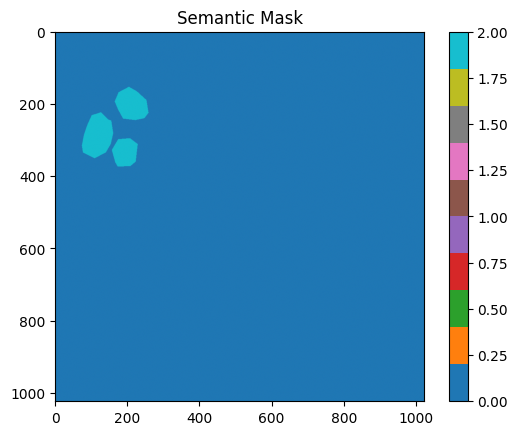

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(mask, cmap="tab10")
plt.colorbar()
plt.title("Semantic Mask")
plt.show()